# Language modeling on THRML: a chain-CRF discrete-diffusion LM

This notebook builds a small **discrete-diffusion language model whose reverse
step is a linear-chain CRF**, and runs that reverse step two ways:

1. **Exactly** — the chain admits exact inference (forward–backward, exact
   joint sampling), so every quantity has a ground-truth oracle;
2. **On THRML** — the same distribution expressed as a THRML factor graph and
   sampled by 2-coloured block Gibbs, the program that Extropic's
   thermodynamic hardware runs natively.

Having both gives an *exactness anchor*: we can measure precisely how sample
fidelity depends on the Gibbs sweep budget the hardware spends — something
most EBM/diffusion setups cannot do, because they have no tractable oracle.

**Setup** (CPU is fine; the whole notebook runs in a few minutes):

```bash
git clone https://github.com/apumutyala/ThermoLM.git && cd ThermoLM
pip install -e external/thrml   # vendored THRML (Apache-2.0)
pip install -e ".[dev,viz]"
```


In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

key = jax.random.key(0)

## 1. A linear-chain CRF as a THRML factor graph

A length-$L$ sequence of categorical variables $x_i \in \{0,\dots,V-1\}$ with

$$p(x) \propto \exp\Big(\sum_i u_i[x_i] + \sum_i W_i[x_i, x_{i+1}]\Big)$$

maps onto THRML directly, because THRML's discrete factor energy is
$-\sum W[\text{gathered}]$ — i.e. it samples $p \propto e^{+\text{score}}$, so
the potential tensors pass through **unchanged**:

- the unary term is a `CategoricalEBMFactor` over one block of all $L$ nodes
  with weights of shape $(L, V)$ — the leading dimension is always "number of
  parallel factor terms";
- the transition term is a `SquareCategoricalEBMFactor` over two blocks
  (`nodes[:-1]`, `nodes[1:]`) with weights $(L-1, V, V)$ — the blocks pair
  **elementwise**, one $V\times V$ table per edge;
- a chain is bipartite, so the even and odd positions form an exact
  2-colouring: two free `Block`s, each updated in one parallel shot.


In [2]:
from thrml import (Block, BlockGibbsSpec, CategoricalNode,
                   FactorSamplingProgram, SamplingSchedule, sample_states)
from thrml.models import (CategoricalEBMFactor, CategoricalGibbsConditional,
                          SquareCategoricalEBMFactor)
from thermolm_jax import chain_marginals

L, V = 12, 5
key, k1, k2 = jax.random.split(key, 3)
unary = jax.random.normal(k1, (L, V))
pairwise = jax.random.normal(k2, (L - 1, V, V))

# nodes are identity handles; structure is static
nodes = [CategoricalNode() for _ in range(L)]
factors = [
    CategoricalEBMFactor([Block(nodes)], unary),                                  # (L, V)
    SquareCategoricalEBMFactor([Block(nodes[:-1]), Block(nodes[1:])], pairwise),  # (L-1, V, V)
]

free_blocks = [Block(nodes[0::2]), Block(nodes[1::2])]  # exact 2-colouring
spec = BlockGibbsSpec(free_blocks, [],
                      {CategoricalNode: jax.ShapeDtypeStruct((), jnp.uint8)})
program = FactorSamplingProgram(
    spec, [CategoricalGibbsConditional(V) for _ in free_blocks], factors, [])
schedule = SamplingSchedule(n_warmup=200, n_samples=1, steps_per_sample=1)

def one_chain(k):
    ks = jax.random.split(k, len(free_blocks) + 1)
    init = [jax.random.randint(ks[i], (len(b.nodes),), 0, V, dtype=jnp.uint8)
            for i, b in enumerate(free_blocks)]
    out = sample_states(ks[-1], program, schedule, init, [], free_blocks)
    x = jnp.zeros((L,), dtype=jnp.int32)
    x = x.at[0::2].set(out[0][-1].astype(jnp.int32))  # results come back per block
    x = x.at[1::2].set(out[1][-1].astype(jnp.int32))
    return x

key, k_s = jax.random.split(key)
samples = np.asarray(jax.vmap(one_chain)(jax.random.split(k_s, 4000)))

# the exactness anchor: compare against exact forward-backward marginals
emp = np.stack([(samples == v).mean(0) for v in range(V)], axis=1)
exact = np.asarray(jnp.exp(chain_marginals(unary, pairwise)))
tv = 0.5 * np.abs(emp - exact).sum(axis=1).mean()
print(f"TV(THRML empirical marginals, exact marginals) = {tv:.4f}  (4000 chains, 200 sweeps)")

TV(THRML empirical marginals, exact marginals) = 0.0096  (4000 chains, 200 sweeps)


## 2. The exactness anchor: fidelity vs sweep budget

On hardware, every Gibbs sweep costs time and energy. How many sweeps does
the reverse step actually need? Because we have the exact marginals, we can
answer quantitatively: run the THRML program at increasing warmup budgets and
plot the total-variation distance to the oracle. Exact FFBS samples at the
same chain count give the finite-sample **noise floor** — the best any
sampler could look with this many chains.


sweeps=   1   TV=0.1625


sweeps=   2   TV=0.0681


sweeps=   5   TV=0.0145


sweeps=  10   TV=0.0187


sweeps=  20   TV=0.0155


sweeps=  50   TV=0.0151


sweeps= 100   TV=0.0151


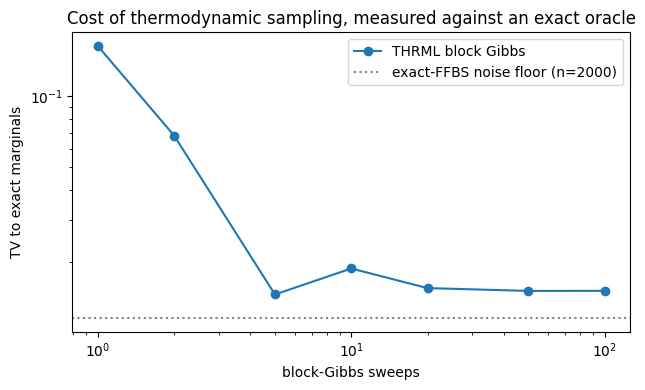

In [3]:
from thermolm_jax import chain_sample
from thermolm_jax.sampling import sample_chain_thrml_single

n_chains = 2000
budgets = [1, 2, 5, 10, 20, 50, 100]

def tv_of(samples):
    e = np.stack([(samples == v).mean(0) for v in range(V)], axis=1)
    return 0.5 * np.abs(e - exact).sum(axis=1).mean()

# exact-sampler noise floor
key, k_f = jax.random.split(key)
ffbs = np.asarray(jax.vmap(lambda k: chain_sample(k, unary, pairwise))(
    jax.random.split(k_f, n_chains)))
floor = tv_of(ffbs)

tvs = []
for b in budgets:
    key, k_b = jax.random.split(key)
    s = np.asarray(sample_chain_thrml_single(unary, pairwise, k_b,
                                             n_chains=n_chains, n_warmup=b))
    tvs.append(tv_of(s))
    print(f"sweeps={b:4d}   TV={tvs[-1]:.4f}")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(budgets, tvs, marker="o", label="THRML block Gibbs")
ax.axhline(floor, ls=":", color="gray", label=f"exact-FFBS noise floor (n={n_chains})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("block-Gibbs sweeps"); ax.set_ylabel("TV to exact marginals")
ax.set_title("Cost of thermodynamic sampling, measured against an exact oracle")
ax.legend(); fig.tight_layout()

For unit-scale random potentials the chain mixes in a handful of sweeps.
The scientifically interesting regime is **trained** potentials — sharper,
lower-entropy, slower-mixing. `scripts/exp_sweep_budget.py --ckpt ...` runs
this exact experiment on a trained model's reverse step; scaling those curves
in $(L, V, \text{connectivity}, T)$ is the research programme in
`docs/RESEARCH_ROADMAP.md`.

## 3. Training the language model

The LM is **masked discrete diffusion**: corrupt $x_0$ by masking each token
with probability $t$, then train a denoiser that maps $(x_t, t)$ to CRF
potentials over the *clean* vocabulary. Because the chain admits exact
inference, training is exact conditional maximum likelihood —
$-\log p_{\text{CRF}}(x_0 \mid \text{potentials})$ via the forward algorithm.
No ELBO, no MCMC, no contrastive approximation in the training loop.


final denoising bits/char ~ 0.939   (unigram baseline 3.799)


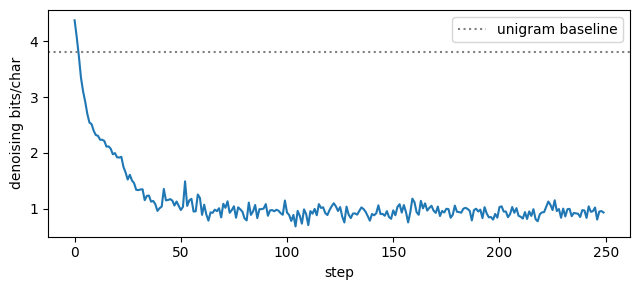

In [4]:
from thermolm_jax import CharTokenizer, make_windows, DiffusionLMConfig, fit
from thermolm_jax.models import unigram_bits_per_char

text = ("to be or not to be that is the question "
        "whether tis nobler in the mind to suffer "
        "the slings and arrows of outrageous fortune "
        "or to take arms against a sea of troubles ") * 40
tok = CharTokenizer.from_text(text)
ids = tok.encode(text)
windows = make_windows(ids, seq_len=24, stride=4)

cfg = DiffusionLMConfig(vocab_size=tok.vocab_size, seq_len=24,
                        hidden_size=96, n_layers=2)
net, params, history = fit(windows, cfg, jax.random.PRNGKey(0),
                           n_iters=250, batch_size=64, lr=3e-3)

baseline = unigram_bits_per_char(ids, tok.vocab_size)
print(f"final denoising bits/char ~ {np.mean(history[-20:]):.3f}"
      f"   (unigram baseline {baseline:.3f})")

fig, ax = plt.subplots(figsize=(6.5, 3))
ax.plot(history)
ax.axhline(baseline, ls=":", color="gray", label="unigram baseline")
ax.set_xlabel("step"); ax.set_ylabel("denoising bits/char"); ax.legend()
fig.tight_layout()

## 4. Generation: exact FFBS vs the THRML path

Generation iteratively unmasks: each reverse step samples the **whole chain
jointly** — so co-committed neighbouring characters coordinate through the
transition term — and commits a growing fraction of positions. The joint
sample can come from the exact sampler (forward-filter backward-sample) or
from the THRML block-Gibbs program. Same distribution, two substrates.


In [5]:
from thermolm_jax import generate

kw = dict(n_samples=4, n_steps=8, temperature=0.8)
samples_exact = np.asarray(generate(params, net, cfg, jax.random.PRNGKey(1),
                                    use_thrml=False, **kw))
samples_thrml = np.asarray(generate(params, net, cfg, jax.random.PRNGKey(1),
                                    use_thrml=True, thrml_warmup=50, **kw))

print("exact FFBS reverse step:")
for s in samples_exact:
    print("  ", repr(tok.decode(s)))
print("THRML block-Gibbs reverse step (50 sweeps/step):")
for s in samples_thrml:
    print("  ", repr(tok.decode(s)))

exact FFBS reverse step:
   'nounsuf tinge t atof the'
   'wsta qunge tof and the s'
   'uermis quer stind ms tha'
   ' sthes theorms s torand '
THRML block-Gibbs reverse step (50 sweeps/step):
   'r or athebkerrms a sube '
   'dhf toro ino of qutinsto'
   'f the alt uboows o  uule'
   ' t s the ar adnine wsesu'


## What this shows

- A **chain-CRF is a natural THRML program**: the potentials your network
  emits are literally the factor weights the hardware consumes — no
  conversion, no sign gymnastics.
- **Exact inference is the measurement instrument**: every hardware-shaped
  approximation (sweep budget, temperature, graph width) can be scored
  against ground truth, turning "does it work?" into a curve.
- The same pairing extends beyond chains: widen the reverse-step graph
  (skip-$k$ bands) and exact inference dies while block Gibbs does not —
  locating the crossover where thermodynamic sampling becomes the *only*
  viable inference is the point of the scaling study.

**Pointers:** [ThermoLM](https://github.com/apumutyala/ThermoLM) (this repo:
validated Ising track, THRML-native training with exact positive phase,
tests vs enumeration) · [THRML docs](https://docs.thrml.ai) ·
[research roadmap](../docs/RESEARCH_ROADMAP.md).
